In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [44]:
df = pd.read_csv('placement.csv')

In [45]:
df.sample(3)

,cgpa,placement_exam_marks,placed
582,7.05,27.0,1
739,6.34,39.0,0
77,7.10,28.0,1


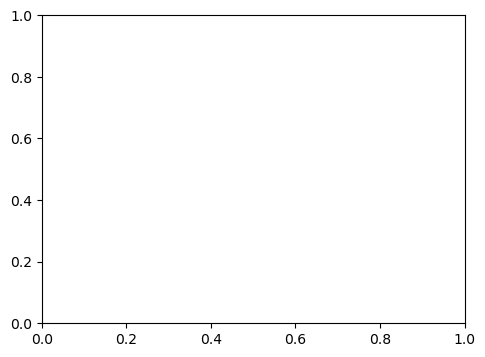

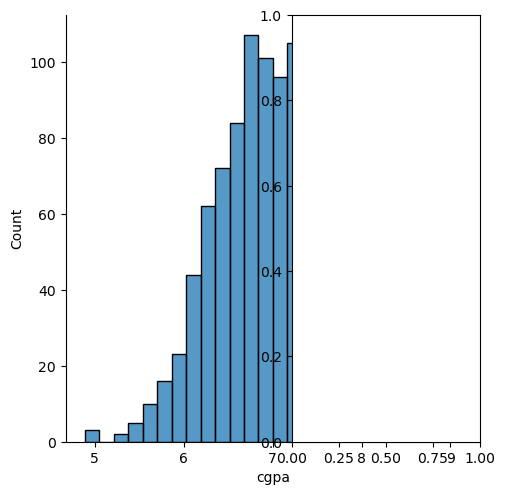

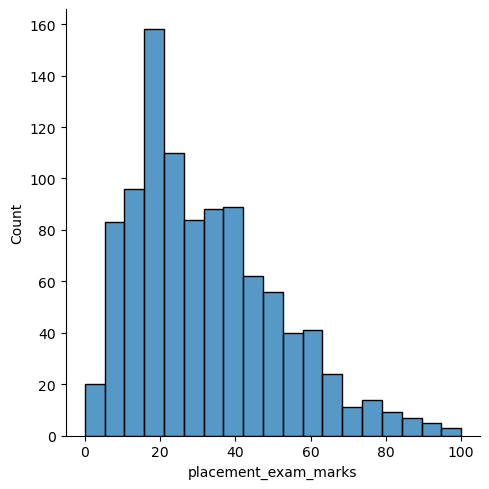

In [34]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.displot(df['cgpa'])

plt.subplot(1,2,2)
sns.displot(df['placement_exam_marks'])

In [35]:
print("Mean value of cgpa",df['cgpa'].mean())
print("STD value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
STD value of cgpa 0.6158978751323894
Min value of cgpa 4.89
Max value of cgpa 9.12


In [36]:
#finding the boundary values
print("Highest allowed" ,df['cgpa'].mean() + 3*df['cgpa'].std())
print("Lowest allowed" ,df['cgpa'].mean() - 3*df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [37]:
#find the outlier
df[(df['cgpa']>8.80) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [38]:
#trimming 

new_df = df[(df['cgpa']<8.80) & (df['cgpa']>5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [39]:
upper_limit= df['cgpa'].mean() + 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() - 3*df['cgpa'].std()

In [40]:
#capping  
lower_limit

np.float64(5.113546374602832)

In [41]:
df['cgpa'] = np.where(
    df['cgpa']>upper_limit,upper_limit,
    np.where(
        df['cgpa']<lower_limit,lower_limit,
        df['cgpa']))

In [42]:
df.shape

(1000, 3)

In [28]:
df['cgpa'].describe

<bound method NDFrame.describe of 0      5.113546
1      5.113546
2      5.113546
3      5.113546
4      5.113546
         ...   
995    8.808934
996    8.808934
997    5.113546
998    5.113546
999    5.113546
Name: cgpa, Length: 1000, dtype: float64>

In [46]:
df.sample()

,cgpa,placement_exam_marks,placed
378,7.27,25.0,1


In [48]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [49]:
print("Mean value of cgpa",df['cgpa'].mean())
print("STD value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
STD value of cgpa 0.6158978751323894
Min value of cgpa 4.89
Max value of cgpa 9.12


In [50]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

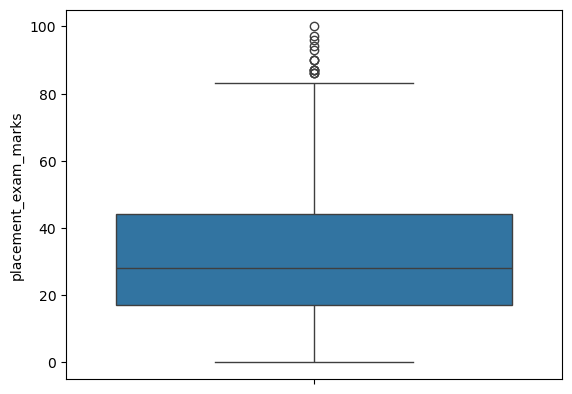

In [51]:
sns.boxplot(df['placement_exam_marks'])

In [53]:
#finding IQR 
per25 = df['placement_exam_marks'].quantile(0.25)
per75 = df['placement_exam_marks'].quantile(0.75)
per25

np.float64(17.0)

In [54]:
per75

np.float64(44.0)

In [55]:
#how to calculate iqr
iqr = per75 - per25

In [56]:
iqr

np.float64(27.0)

In [57]:
upper_limit= per75 +1.5*iqr 
lower_limit = per25 - 1.5*iqr

In [58]:
lower_limit

np.float64(-23.5)

In [59]:
upper_limit

np.float64(84.5)

In [61]:
#____________how to find outlier______________

In [63]:
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [64]:
#_________trimming

In [70]:
new_df = df[df['placement_exam_marks']<upper_limit]
new_df.shape

(985, 3)

In [71]:
#_____capping

In [73]:
ndc= df.copy()

ndc['placement_exam_marks'] = np.where(
    ndc['placement_exam_marks']>upper_limit,upper_limit,
    np.where(
        ndc['placement_exam_marks']<lower_limit,lower_limit,
        ndc['placement_exam_marks']))

In [76]:
ndc.shape

(1000, 3)

In [104]:
df = sns.load_dataset('penguins')

In [78]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [82]:
q1 = df['body_mass_g'].quantile(0.25)
q1

np.float64(3550.0)

In [83]:
q3 = df['body_mass_g'].quantile(0.75)
q3

np.float64(4750.0)

In [85]:
IQR = q3-q1
IQR

np.float64(1200.0)

In [89]:
lower = q1 - 1.5*IQR
lower

np.float64(1750.0)

In [90]:
higher = q3 + 1.5 * IQR
higher

np.float64(6550.0)

In [92]:
(df['body_mass_g'] < lower) | (df['body_mass_g'] > higher)

0      False
1      False
2      False
3      False
4      False
       ...  
339    False
340    False
341    False
342    False
343    False
Name: body_mass_g, Length: 344, dtype: bool

In [93]:
outliers = df[(
    df['body_mass_g']<lower) |
    (df['body_mass_g']>higher)]

In [94]:
outliers

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex


In [95]:
lower = df['body_mass_g'].quantile(0.01)
upper = df['body_mass_g'].quantile(0.99)

In [97]:
upper

np.float64(5979.499999999999)

In [98]:
outliers = df[(
    df['body_mass_g']<lower) |
    (df['body_mass_g']>upper)]

In [99]:
outliers['body_mass_g']

58     2850.0
64     2850.0
190    2700.0
237    6300.0
253    6050.0
297    6000.0
337    6000.0
Name: body_mass_g, dtype: float64

In [107]:
from scipy.stats import zscore

z_scores = zscore(df['body_mass_g'])

In [109]:
outliers = df[abs(z_scores) > 3]

In [105]:
abs(z_scores) > 3

z_scores = zscore(df['body_mass_g'])

In [110]:
outliers['body_mass_g']

Series([], Name: body_mass_g, dtype: float64)

In [111]:
Q1 = 20
Q3 = 50
IQR = 30

In [115]:
w = Q3 + 1.5 * IQR
w

95.0